<a href="https://colab.research.google.com/github/RAseng77/AIFFEL_QUEST_RS/blob/master/Exploration/Ex01/aiffel_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p /content/data/models

In [2]:
!mkdir -p /content/data/images

In [3]:
!pip install cmake

In [4]:
!pip install opencv-python

In [5]:
!pip install -y dlib


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


In [6]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib
print("HI")

HI


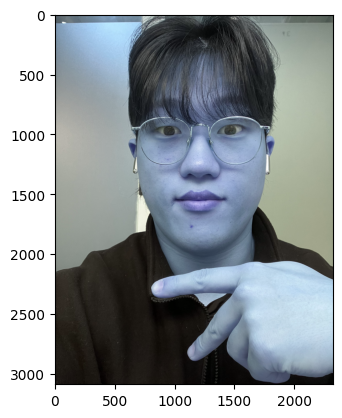

In [7]:
home_dir = os.getenv("HOME")
my_image_path = os.path.join(home_dir, "/content/data/images/sunghyun.png")
img_bgr = cv2.imread(my_image_path)
img_show = img_bgr.copy()
plt.imshow(img_bgr)
plt.show()

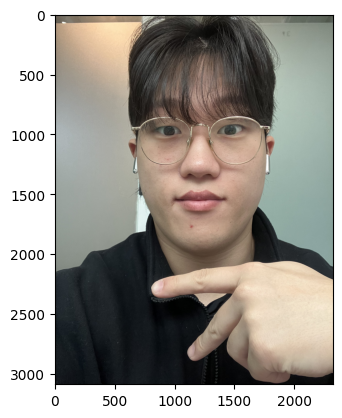

In [8]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

In [9]:
detector_hog = dlib.get_frontal_face_detector()
dlib_rects = detector_hog(img_rgb)
print("HI")

HI


In [10]:
print(dlib_rects)

rectangles[[(562, 562) (1894, 1894)]]


562 562 1894 1894


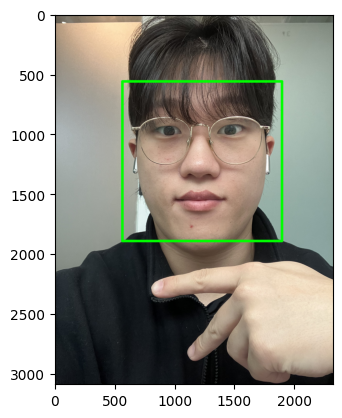

In [11]:
for dlib_rect in dlib_rects:
  l = dlib_rect.left()
  t = dlib_rect.top()
  r = dlib_rect.right()
  b = dlib_rect.bottom()
  print(l, t, r, b)

  cv2.rectangle(img_show, (l,t), (r, b), (0, 255, 0), 20, lineType=cv2.LINE_AA)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [12]:

!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2


!mv shape_predictor_68_face_landmarks.dat.bz2 /content/data/models/


!bzip2 -d /content/data/models/shape_predictor_68_face_landmarks.dat.bz2


!ls -l /content/data/models/

--2026-01-16 07:03:54--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-01-16 07:03:54--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  50.6MB/s    in 1.2s    

2026-01-16 07:03:55 (50.6 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

total 97360
-rw-r--r-- 1 root root 99693937 Jul 24  2015 shape_predictor_68_face_landmarks.dat


In [13]:
model_path = os.path.join(home_dir, "/content/data/models/shape_predictor_68_face_landmarks.dat")

landmark_predictor = dlib.shape_predictor(model_path)

print("HI")

HI


In [14]:
list_landmarks = []

for dlib_rect in dlib_rects:
  points = landmark_predictor(img_rgb, dlib_rect)

  list_points = list(map(lambda p: (p.x, p.y), points.parts()))

  list_landmarks.append(list_points)

print(len(list_landmarks[0]))

68


In [15]:
print(list_landmarks)

[[(667, 988), (661, 1139), (676, 1300), (712, 1457), (769, 1603), (847, 1746), (950, 1870), (1073, 1955), (1213, 1977), (1357, 1945), (1491, 1849), (1607, 1725), (1700, 1587), (1765, 1434), (1798, 1271), (1810, 1111), (1805, 957), (751, 836), (823, 747), (938, 714), (1053, 730), (1149, 782), (1281, 781), (1373, 721), (1486, 698), (1595, 720), (1675, 800), (1211, 956), (1207, 1060), (1203, 1160), (1197, 1266), (1084, 1363), (1143, 1379), (1205, 1395), (1269, 1378), (1331, 1363), (854, 976), (911, 943), (983, 945), (1055, 995), (982, 1011), (907, 1009), (1375, 986), (1436, 929), (1507, 922), (1570, 949), (1514, 989), (1441, 996), (1004, 1562), (1079, 1517), (1142, 1483), (1200, 1498), (1256, 1480), (1326, 1508), (1412, 1549), (1330, 1602), (1265, 1638), (1205, 1649), (1142, 1641), (1079, 1610), (1039, 1561), (1143, 1548), (1201, 1552), (1257, 1545), (1373, 1552), (1260, 1554), (1203, 1564), (1146, 1557)]]


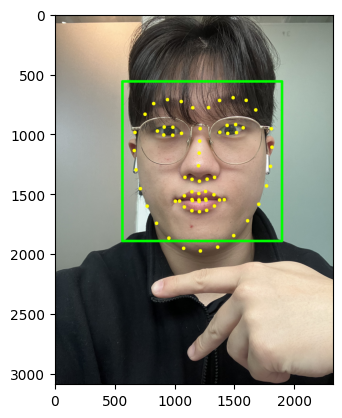

In [16]:
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 15, (0,255,255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

plt.imshow(img_show_rgb)

plt.show()

In [17]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    print(landmark[62])
    x = landmark[33][0]
    y = (landmark[33][1] + landmark[51][1]) // 2
    w = h = dlib_rect.width()
    print(f'(x,y) : ({x}, {y})')
    print(f'(w,h) : ({w}, {h})')


(1201, 1552)
(x,y) : (1205, 1446)
(w,h) : (1333, 1333)


(1333, 1333, 3)


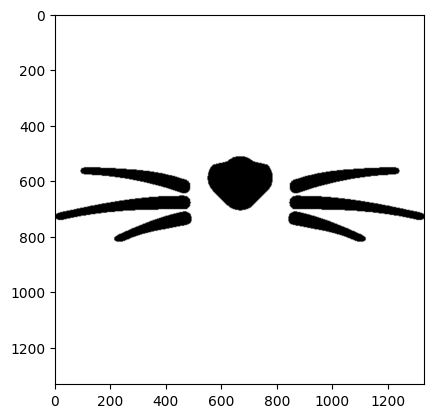

In [18]:
sticker_path = os.path.join(home_dir, "/content/data/images/cat-whiskers.png")
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w, h))
print(img_sticker.shape)
plt.imshow(img_sticker)
plt.show()

In [19]:
refined_x = x - w //2
refined_y = y - h // 2
print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (539,780)


In [20]:
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:]
    refined_y = 0

print(f'(x,y) : ({refined_x}, {refined_y})')

(x,y) : (539, 780)


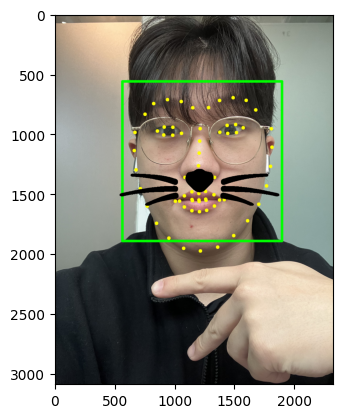

In [21]:
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]

img_sticker_gray = cv2.cvtColor(img_sticker, cv2.COLOR_BGR2GRAY)
ret, mask = cv2.threshold(img_sticker_gray, 150, 255, cv2.THRESH_BINARY)


mask_3ch = cv2.merge([mask, mask, mask])


img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(mask_3ch == 255, sticker_area, 0).astype(np.uint8)


plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

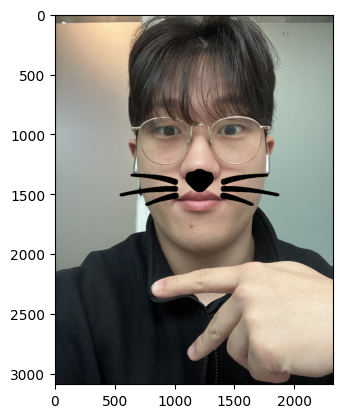

In [22]:
sticker_area = img_bgr[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]

img_bgr[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(mask_3ch == 255, sticker_area, 0).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()